In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [19]:
x = np.random.randint(-40,40,size=(1000,64))
y = 1 / (1 + np.exp(-np.reshape([i[0]*3 + i[1]*4 for i in x], (-1, 1))))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [20]:
model = Sequential([
    
    Dense(32, activation='relu', input_shape=(64,)),
    Dense(1, activation='sigmoid'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumo
model.summary()



c:\Users\jose.sales\AppData\Local\miniconda3\envs\ilumpy\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3375 - loss: 8.6585 - val_accuracy: 0.3625 - val_loss: 6.5310
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3375 - loss: 5.5867 - val_accuracy: 0.3750 - val_loss: 5.1083
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3906 - loss: 3.7115 - val_accuracy: 0.3875 - val_loss: 4.0101
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4516 - loss: 2.5305 - val_accuracy: 0.4250 - val_loss: 3.1485
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5125 - loss: 1.8587 - val_accuracy: 0.4625 - val_loss: 2.6360
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5422 - loss: 1.4345 - val_accuracy: 0.4812 - val_loss: 2.2983
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5734 - loss: 1.1258 - val_accuracy: 0.4750 - val_loss: 2.0549
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5797 - loss: 0.8854 - val_accuracy: 0.5000 - v

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


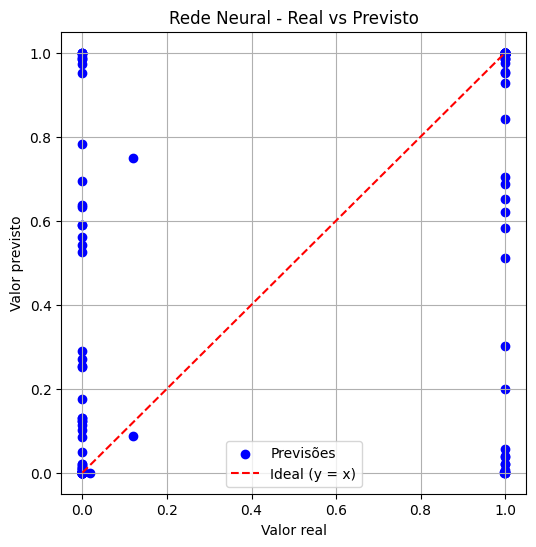

In [22]:
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', label='Previsões')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Ideal (y = x)'
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Rede Neural - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

In [23]:
item = [0]*64
item[0]=1
item[1]=.5
model.predict(np.array([item]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[0.5862461]], dtype=float32)

In [24]:
""""
weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


#Transforma float para Q16
def float_to_q16(val):
    if np.isnan(val):
        return 0
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))
    return max(INT32_MIN, min(INT32_MAX, fixed))

# Endereço: [layer(3 bits)][is_bias(1 bit)][neuron(4 bits)][input_idx(4 bits)]
def build_addr(layer, is_bias, neuron, idx):
    return (layer << 9) | (is_bias << 8) | (neuron << 4) | idx

# Export mem
mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i+1].numpy()

    n_neurons, n_inputs = kernel.shape

    #Peso
    for n in range(n_neurons):
        for inp in range(n_inputs):

            if n >= 16 or inp >= 16:
                raise ValueError("Excedeu limite de 4 bits")

            addr = build_addr(layer_idx, 0, n, inp)
            mem[addr] = float_to_q16(kernel[n][inp])

    #Viés
    for n in range(n_neurons):

        if n >= 16:
            raise ValueError("Excedeu limite de 4 bits")

        addr = build_addr(layer_idx, 1, n, 0)
        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2



max_addr = max(mem.keys())

with open("weights.mem", "w") as f:
    for addr in range(max_addr + 1):
        val = mem.get(addr, 0)

        # two's complement se negativo
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{val:08x}\n")

print("Arquivo salvo: weights.mem")

"""

'"\nweights = model.weights\n\nFRAC = 16\nSCALE = 1 << FRAC\n\nINT32_MAX = 2**31 - 1\nINT32_MIN = -(2**31)\n\n\n#Transforma float para Q16\ndef float_to_q16(val):\n    if np.isnan(val):\n        return 0\n    if np.isposinf(val):\n        return INT32_MAX\n    if np.isneginf(val):\n        return INT32_MIN\n\n    fixed = int(np.round(val * SCALE))\n    return max(INT32_MIN, min(INT32_MAX, fixed))\n\n# Endereço: [layer(3 bits)][is_bias(1 bit)][neuron(4 bits)][input_idx(4 bits)]\ndef build_addr(layer, is_bias, neuron, idx):\n    return (layer << 9) | (is_bias << 8) | (neuron << 4) | idx\n\n# Export mem\nmem = {}\n\nlayer_idx = 0\ni = 0\n\nwhile i < len(weights):\n\n    kernel = weights[i].numpy().T\n    bias   = weights[i+1].numpy()\n\n    n_neurons, n_inputs = kernel.shape\n\n    #Peso\n    for n in range(n_neurons):\n        for inp in range(n_inputs):\n\n            if n >= 16 or inp >= 16:\n                raise ValueError("Excedeu limite de 4 bits")\n\n            addr = build_addr(

In [25]:
import numpy as np

weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)

# ============================================================
# FLOAT -> Q16.16
# ============================================================

def float_to_q16(val):

    if np.isnan(val):
        return 0

    if np.isposinf(val):
        return INT32_MAX

    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))

    return max(INT32_MIN, min(INT32_MAX, fixed))

# ============================================================
# ADDRESS FORMAT
#
# [31:24] -> layer
# [23]    -> is_bias
# [22]    -> is_lstm
# [21:20] -> gate
# [19:10] -> neuron
# [9]     -> recurrent
# [8:0]   -> idx
# ============================================================

def build_addr(
    layer,
    is_bias,
    is_lstm,
    gate,
    neuron,
    recurrent,
    idx
):

    addr = 0

    addr |= (layer      & 0xFF) << 24
    addr |= (is_bias    & 0x1 ) << 23
    addr |= (is_lstm    & 0x1 ) << 22
    addr |= (gate       & 0x3 ) << 20
    addr |= (neuron     & 0x3FF) << 10
    addr |= (recurrent  & 0x1 ) << 9
    addr |= (idx        & 0x1FF)

    return addr

# ============================================================
# EXPORT
# ============================================================

mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i + 1].numpy()

    n_neurons, n_inputs = kernel.shape

    # ========================================================
    # WEIGHTS
    # ========================================================

    for n in range(n_neurons):

        for inp in range(n_inputs):

            addr = build_addr(
                layer      = layer_idx,
                is_bias    = 0,
                is_lstm    = 0,
                gate       = 0,
                neuron     = n,
                recurrent  = 0,
                idx        = inp
            )

            mem[addr] = float_to_q16(kernel[n][inp])

    # ========================================================
    # BIASES
    # ========================================================

    for n in range(n_neurons):

        addr = build_addr(
            layer      = layer_idx,
            is_bias    = 1,
            is_lstm    = 0,
            gate       = 0,
            neuron     = n,
            recurrent  = 0,
            idx        = 0
        )

        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2

# ============================================================
# WRITE FILE
# ============================================================

with open("weights.mem", "w") as f:

    for addr in sorted(mem.keys()):

        val = mem[addr]

        # two's complement
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{addr:08x} {val:08x}\n")

print("Arquivo salvo: weights.mem")

Arquivo salvo: weights.mem
